In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import (
    Dense,
    GlobalAveragePooling2D,
    Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

In [2]:
TRAIN_DIR = "dataset/train"
TEST_DIR = "dataset/test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names

print("Classes:", class_names)

Found 963 files belonging to 2 classes.
Found 963 files belonging to 2 classes.
Classes: ['dandelion', 'sunflower']


In [4]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

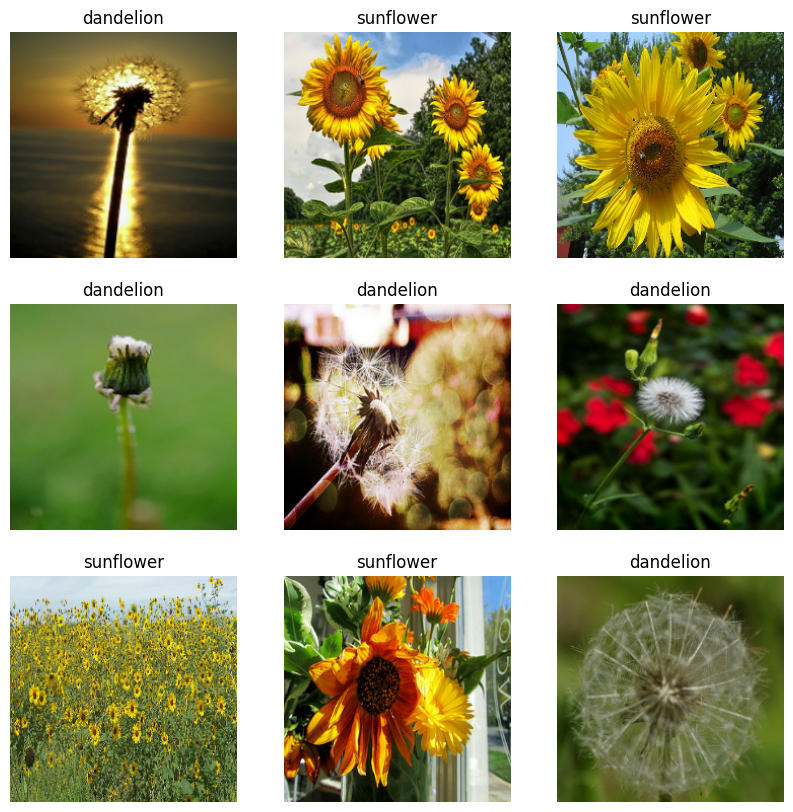

In [5]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [6]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2)
])

In [7]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224,224,3))

x = data_augmentation(inputs)

x = tf.keras.layers.Rescaling(1./255)(x)

x = base_model(x, training=False)

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

outputs = Dense(1, activation="sigmoid")(x)

model = Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [8]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "best_model.h5",
        monitor="val_accuracy",
        save_best_only=True
    )
]

In [9]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4984 - loss: 0.6976

31/31 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.5161 - loss: 0.6957 - val_accuracy: 0.4953 - val_loss: 0.7018
Epoch 2/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.4839 - loss: 0.7067 - val_accuracy: 0.4953 - val_loss: 0.6994
Epoch 3/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.4943 - loss: 0.7049 - val_accuracy: 0.4953 - val_loss: 0.7031
Epoch 4/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.4912 - loss: 0.7013 - val_accuracy: 0.4953 - val_loss: 0.7049
Epoch 5/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.4995 - loss: 0.7077 - val_accuracy: 0.4953 - val_loss: 0.6922
Epoch 6/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.5317 - loss: 0.7057 - val_accuracy: 0.4953 - val_loss: 0.7052
Epoch 7/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.4891 - loss: 0.7055 - val_accuracy: 0.4953 - val_loss: 0.6942
Epoch 8/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.5005 - loss: 0.7020 - val_accuracy: 0.4953 - val_loss: 0.6920
Epo

31/31 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.4528 - loss: 0.7110 - val_accuracy: 0.7082 - val_loss: 0.6915
Epoch 11/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.4953 - loss: 0.7002 - val_accuracy: 0.4953 - val_loss: 0.6977
Epoch 12/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.4735 - loss: 0.7046 - val_accuracy: 0.4953 - val_loss: 0.6922
Epoch 13/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.4964 - loss: 0.6966 - val_accuracy: 0.4953 - val_loss: 0.6923
Epoch 14/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.4839 - loss: 0.6962 - val_accuracy: 0.4953 - val_loss: 0.6914
Epoch 15/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.4995 - loss: 0.7022 - val_accuracy: 0.4953 - val_loss: 0.6916


In [10]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.5213 - loss: 0.7016 - val_accuracy: 0.4953 - val_loss: 0.6910
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.4964 - loss: 0.7046 - val_accuracy: 0.5213 - val_loss: 0.6907
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.5130 - loss: 0.7029 - val_accuracy: 0.5047 - val_loss: 0.6915
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.5161 - loss: 0.6975 - val_accuracy: 0.5047 - val_loss: 0.6933
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.5234 - loss: 0.6941 - val_accuracy: 0.5047 - val_loss: 0.6961
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.5389 - loss: 0.6985 - val_accuracy: 0.5047 - val_loss: 0.6992
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.5441 - loss: 0.6868 - val_accuracy: 0.5047 - val_loss: 0.7009


In [11]:
model.save("best_model.h5")

print("Model saved successfully.")

Model saved successfully.


In [ ]:
import os
from PIL import Image
import numpy as np

img_path = "sample.jpg"

if not os.path.exists(img_path):
    alt = None
    for cls in ("sunflower", "dandelion"):
        p = os.path.join("dataset", "test", cls)
        if os.path.isdir(p):
            files = [f for f in os.listdir(p) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
            if files:
                alt = os.path.join(p, files[0])
                break
    if alt:
        print(f"'{img_path}' not found — using {alt}")
        img_path = alt
    else:
        raise FileNotFoundError(f"'{img_path}' not found and no images in dataset/test/* were found. Place an image named 'sample.jpg' in the working directory or update `img_path`.")

image = Image.open(img_path).convert("RGB")
image = image.resize((224,224))

img_array = np.array(image).astype("float32") / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = float(model.predict(img_array)[0][0])

if prediction > 0.5:
    label = "Sunflower"
    confidence = prediction * 100
else:
    label = "Dandelion"
    confidence = (1 - prediction) * 100

print("Prediction:", label)
print("Confidence:", round(confidence,2), "%")

FileNotFoundError: [Errno 2] No such file or directory: 'sample.jpg'